In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter

In [2]:
## Load the Zooms
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

#name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial'] + ['bf_sim']
name_list = ['bf_sim']

snap = 264

name_list = ['fiducial']

zoom = {}
for i in range(len(name_list)):
    base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/"+name_list[i]+"/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), use_ids=True, numpart=4320)



2026-06-05 22:40:14,397 bacco.sims : Initialising simulation Default
2026-06-05 22:40:14,399 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-06-05 22:40:14,461 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-06-05 22:40:14,474 bacco.sims : ...done in 0.0769 s


In [4]:
zoom['fiducial'].gas

2026-06-05 22:40:23,302 bacco.sims : Read data for 14571274/116718675 particles...


/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264.0.hdf5


2026-06-05 22:40:26,635 bacco.sims : Read data for 14571274/116718675 particles...
2026-06-05 22:40:26,656 bacco.sims : Read data for 14629010/116718675 particles...
2026-06-05 22:40:30,353 bacco.sims : Read data for 14629010/116718675 particles...
2026-06-05 22:40:30,380 bacco.sims : Read data for 14583559/116718675 particles...
2026-06-05 22:40:34,040 bacco.sims : Read data for 14583559/116718675 particles...
2026-06-05 22:40:34,052 bacco.sims : Read data for 14595036/116718675 particles...
2026-06-05 22:40:37,749 bacco.sims : Read data for 14595036/116718675 particles...
2026-06-05 22:40:37,757 bacco.sims : Read data for 14567125/116718675 particles...
2026-06-05 22:40:41,443 bacco.sims : Read data for 14567125/116718675 particles...
2026-06-05 22:40:41,464 bacco.sims : Read data for 14624517/116718675 particles...
2026-06-05 22:40:45,246 bacco.sims : Read data for 14624517/116718675 particles...
2026-06-05 22:40:45,266 bacco.sims : Read data for 14573097/116718675 particles...
2026

{'pos': array([[ 89.32294 , 319.65054 , 373.0927  ],
        [ 89.34123 , 319.6771  , 373.0598  ],
        [ 89.3179  , 319.64896 , 373.08984 ],
        ...,
        [ 49.192806, 179.44133 , 184.1585  ],
        [ 49.30862 , 179.06834 , 183.70738 ],
        [ 48.473515, 179.53217 , 183.2628  ]], dtype=float32),
 'vel': array([[ 281.75  ,  308.    ,   81.9375],
        [ 532.    ,  153.    ,  550.5   ],
        [ 295.    ,  286.25  ,  101.    ],
        ...,
        [ 180.25  , -156.125 ,  -97.0625],
        [ 178.75  , -158.75  , -102.375 ],
        [ 151.    , -152.5   , -116.5625]], dtype=float32),
 'ids': array([169511089, 413858187, 378239377, ..., 149741221, 149741223,
        149741489], dtype=uint64),
 'mass': array([0.00222886, 0.00265714, 0.00332378, ..., 0.01638452, 0.01479325,
        0.01623126], dtype=float32),
 'add_prop': {'InternalEnergy': array([1.8878305e+06, 1.7418204e+06, 1.9355520e+06, ..., 2.0852932e+01,
         1.7088945e+01, 3.9623260e+01], dtype=float32),
  'E

In [13]:
f_b = zoom['fiducial'].Cosmology.pars['omega_baryon'] / zoom['fiducial'].Cosmology.pars['omega_matter']

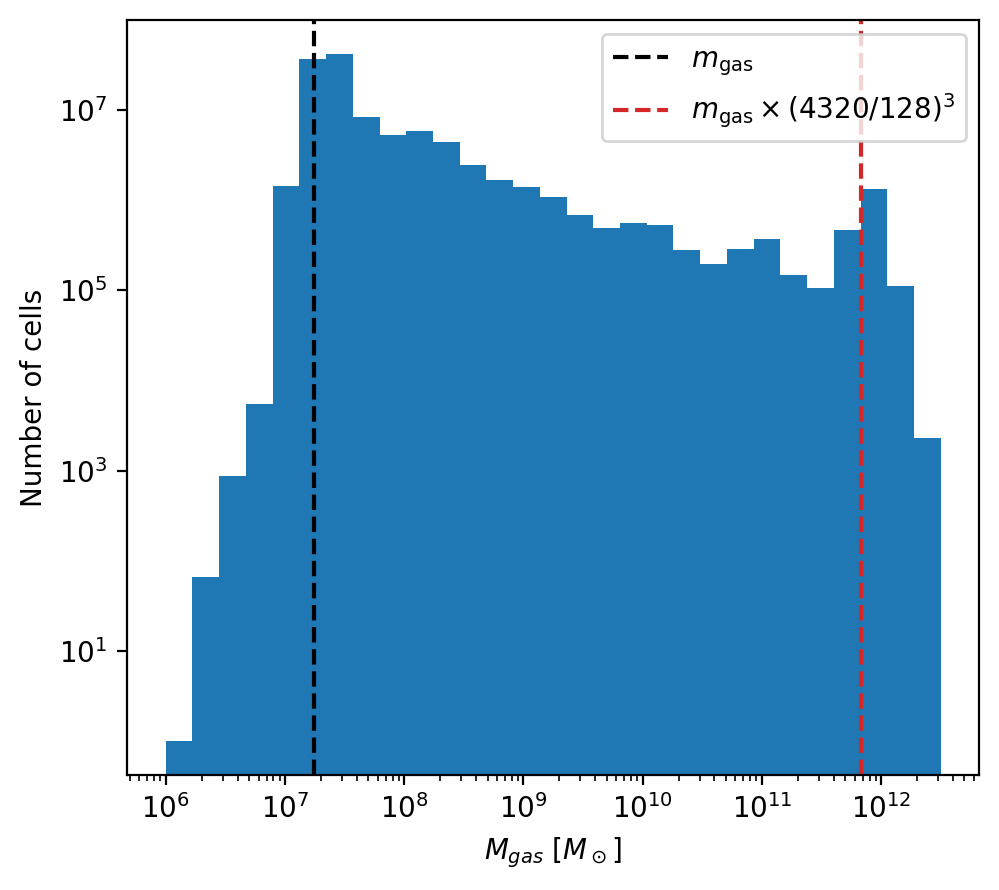

In [20]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_ylabel('Number of cells')
ax.set_xlabel('$M_{gas}$ [$M_\odot$]')
ax.set_xscale('log')
ax.hist(zoom['fiducial'].gas['mass']*1e10, bins=np.logspace(6,12.5,30), log=True)
ax.axvline(zoom['fiducial'].header['ParticleMass'] * 1e10 * f_b, color='k', ls='--', label='$m_{\mathrm{gas}}$')
ax.axvline(zoom['fiducial'].header['ParticleMass'] * (4320/128)**3 * 1e10 * f_b, color='C3', ls='--', label='$m_{\mathrm{gas}} \\times (4320/128)^3$')

ax.legend()

In [26]:
center = zoom['fiducial'].fof['halo_pos'][0,:]

2026-06-05 22:53:27,512 bacco.sims : Reading 139956 items for GroupPos


In [36]:
gas_pos = zoom['fiducial'].gas['pos'] - center
gas_mass = zoom['fiducial'].gas['mass']*1e10
mask_gas = ( np.abs(gas_pos[:,0])<20 ) & ( np.abs(gas_pos[:,1]) < 20) & ( np.abs(gas_pos[:,2]) < 20)

In [33]:
dm_pos = zoom['fiducial'].dm['pos'] - center
dm_mass = 1e10 * np.ones(dm_pos.shape[0]) * zoom['fiducial'].header['ParticleMass']
mask = ( np.abs(dm_pos[:,0])<20 ) & ( np.abs(dm_pos[:,1]) < 20) & ( np.abs(dm_pos[:,2]) < 20) 

xy_range = [[-20, 20], [-20, 20]]

cell = 40 / 1000

hist_dm = np.histogram2d(dm_pos[mask][:,0], dm_pos[mask][:,1], weights=dm_mass[mask], bins=1000, range=xy_range)

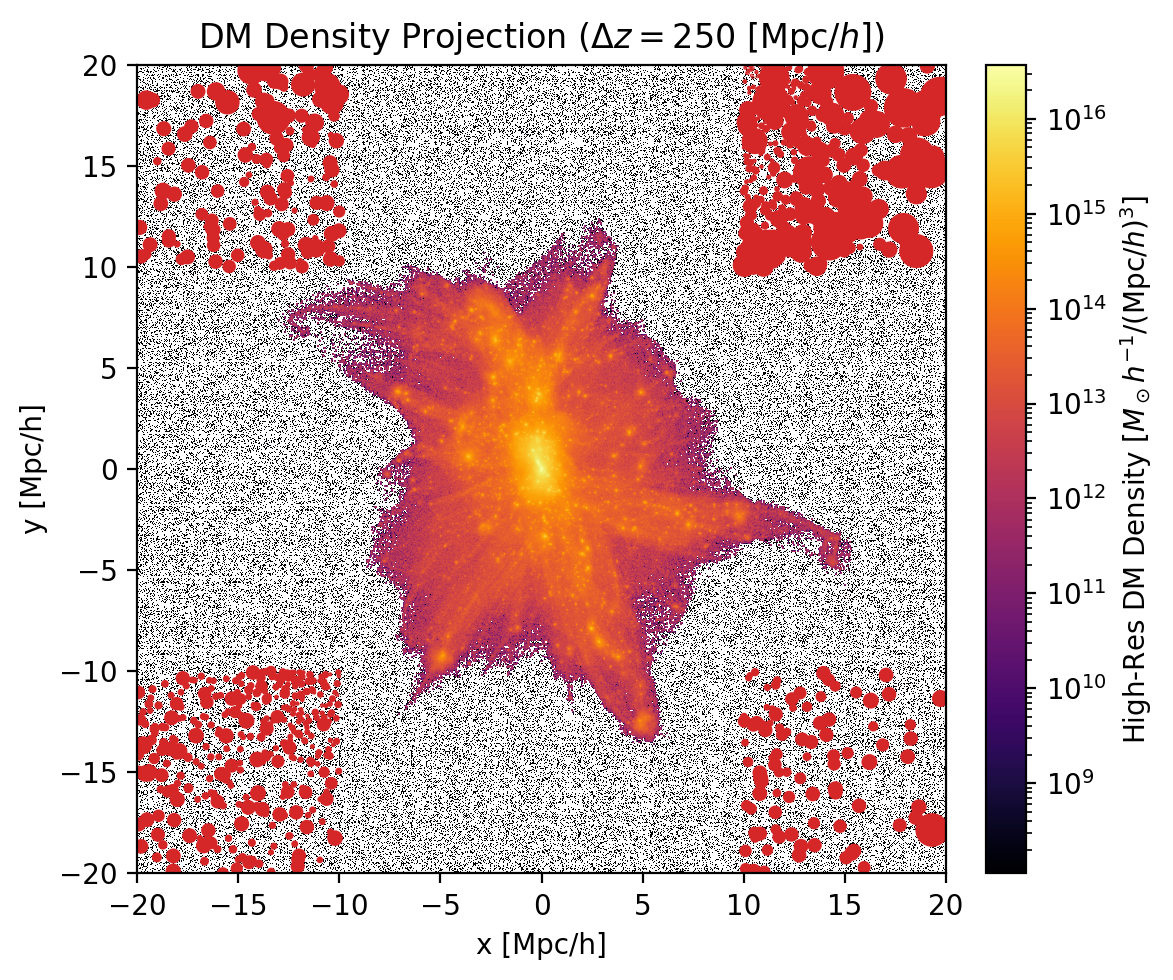

In [48]:
fig, ax = plt.subplots(dpi=200, figsize=(6, 5))

# --- per-direction distance cut, combined with your existing mask ---
d = np.abs(gas_pos)                                   # |x|, |y|, (|z|) from center=0
shell = np.all((d >= 10) & (d <= 20), axis=1)         # in [10,20] along EVERY axis
mask = shell

# --- DM background (unchanged) ---
h_dm = hist_dm[0].T / cell**3
box_size = 40
extent = [-box_size/2, box_size/2, -box_size/2, box_size/2]

im_dm = ax.imshow(h_dm, cmap='inferno',
                  norm=LogNorm(vmin=np.median(dm_mass), vmax=np.max(h_dm)),
                  origin='lower', extent=extent)

ax.set_xlabel("x [Mpc/h]")
ax.set_ylabel("y [Mpc/h]")
ax.set_title(r"DM Density Projection ($\Delta z = 250$ [Mpc/$h$])")

cbar = fig.colorbar(im_dm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'High-Res DM Density [$M_\odot h^{-1} / ($Mpc$/h)^3$]')

# --- gas scatter, only the selected shell ---
ax.scatter(gas_pos[mask, 0], gas_pos[mask, 1],
           s=gas_mass[mask] / ( 300 * dm_mass[0] * f_b), color='C3')

plt.tight_layout()
plt.show()